# EXPLORATORIO
## Wavelet Coefficients Visualizations

# 0. Importaciones y Configuración

In [8]:
from astropy.io import fits
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from astropy import constants as const
import os

import sys

sys.path.append('../../src')

from wavelet_denoising import Wavelet2D1DTransform, Denoiser2D1D
from dicts_wavelets import transformaciones_1d, transformaciones_2d, filtros

DATA_DIR = '/Users/kuky/Documents/practica/Denoiser3D-IFU/data'
IMGS_DIR = '/Users/kuky/Documents/practica/Denoiser3D-IFU/data/imgs'

## 0.1. Definición de funciones

In [2]:
def wavelet_coefficients_visualization(cube_name, slice_index=None,
T1D='T01_MALLAT', T2D='TO_PAVE_BSPLINE', F1D='F_MALLAT_7_9', F2D='F_MALLAT_7_9'):
    """
    Visualización de los coeficientes wavelet de un cubo 3D.

    Parameters
    ----------
    cube_name : str
        Nombre del cubo a visualizar.

    Returns
    -------
    None
    """

    hdu = fits.open(os.path.join(DATA_DIR, f'{cube_name}.fits'))

    if len(hdu[0].data.shape) == 4:
        cube = hdu[0].data[0]
    else:
        cube = hdu[0].data
    cube = np.nan_to_num(cube, nan=0.0) # Se reemplazan los NaN por 0

    n2d = int(np.log2(cube.shape[1]))
    n1d = int(np.log2(cube.shape[0]))

    inds, shapes, coeffs = Wavelet2D1DTransform(
        transform_1d=transformaciones_1d[T1D],
        transform_type=transformaciones_2d[T2D],
        filter_1d=filtros[F1D],
        filter_2d=filtros[F2D],
    ).decompose(
        cube,
        num_scales_2d=n2d,
        num_scales_1d=n1d,
    )

    fig, axes = plt.subplots(
        n1d, n2d,
        figsize=(2 * n2d, 2 * n1d),
        squeeze=False,
    )

    for i in range(n2d):           # eje columnas: escala 2D
        for j in range(n1d):       # eje filas:    escala 1D
            nx, ny, nz = shapes[i][j]
            start, end = inds[i][j]
            sub = coeffs[start:end].reshape((nz, ny, nx))
            if slice_index is None:
                img = sub[nz // 2]
            else:
                img = sub[slice_index]
               
            vmax = np.max(np.abs(img)) + 1e-12       # rango simétrico por celda
            ax = axes[j, i]
            ax.imshow(img, cmap="RdBu_r", vmin=-vmax, vmax=vmax, origin="lower")
            ax.set_xticks([]); ax.set_yticks([])

            if j == 0:
                ax.set_title(rf"$n_{{2D}} = {i+1}$")
            if i == 0:
                ax.set_ylabel(rf"$n_{{1D}} = {j+1}$", rotation=0, labelpad=30, va="center")

    plt.tight_layout()
    plt.show()

    return None

# 1. Carga del cubo

In [3]:
DATA_TYPE = 'real_cubes'
TYPE_CUBE = 'condor01comb'
CUBE_NAME = 'CONDOR01COMB_CO32_15kms_r05._subcube1_wavelets_iterative_soft_3'

hdu = fits.open(os.path.join(DATA_DIR, DATA_TYPE, TYPE_CUBE, f'{CUBE_NAME}.fits'))
cube = hdu[0].data
cube = np.nan_to_num(cube, nan=0.0) # Se reemplazan los NaN por 0

y = cube.copy() # Cubo de referencia de estadísticas. (No tenemos por lo que usamos el cubo original)

print(cube.shape)

(48, 96, 96)


In [4]:
num_scales_2d_cube = int(np.log2(cube.shape[1]))
num_scales_1d_cube = int(np.log2(cube.shape[0]))

print(num_scales_2d_cube, num_scales_1d_cube)

6 5


In [5]:
inds, shapes, coeffs = Wavelet2D1DTransform().decompose(
    cube,
    num_scales_2d=num_scales_2d_cube,
    num_scales_1d=num_scales_1d_cube,
)

In [6]:
i = 0 # Escala 2D
j = 0 # Escala 1D


print('índices para acceder a los coeficientes por escala:',inds[i][j])

start = inds[i][j][0]
end = inds[i][j][1]

print('coeficientes para el par de escala (i,j):',coeffs[start:end])

nx, ny, nz = shapes[i][j]

print('dimensión nx, ny, nz:',nx, ny, nz)

start, end = inds[i][j]
subband = coeffs[start:end].reshape((nz, ny, nx))   # eje 0 = espectral

slice_2d = subband[subband.shape[0] // 2]   # forma (ny, nx). Estamos tomando el slice espectral central.

índices para acceder a los coeficientes por escala: (5, 221189)
coeficientes para el par de escala (i,j): [ 0.0000000e+00  0.0000000e+00  0.0000000e+00 ... -1.1350547e-09
  0.0000000e+00  0.0000000e+00]
dimensión nx, ny, nz: 96 96 24


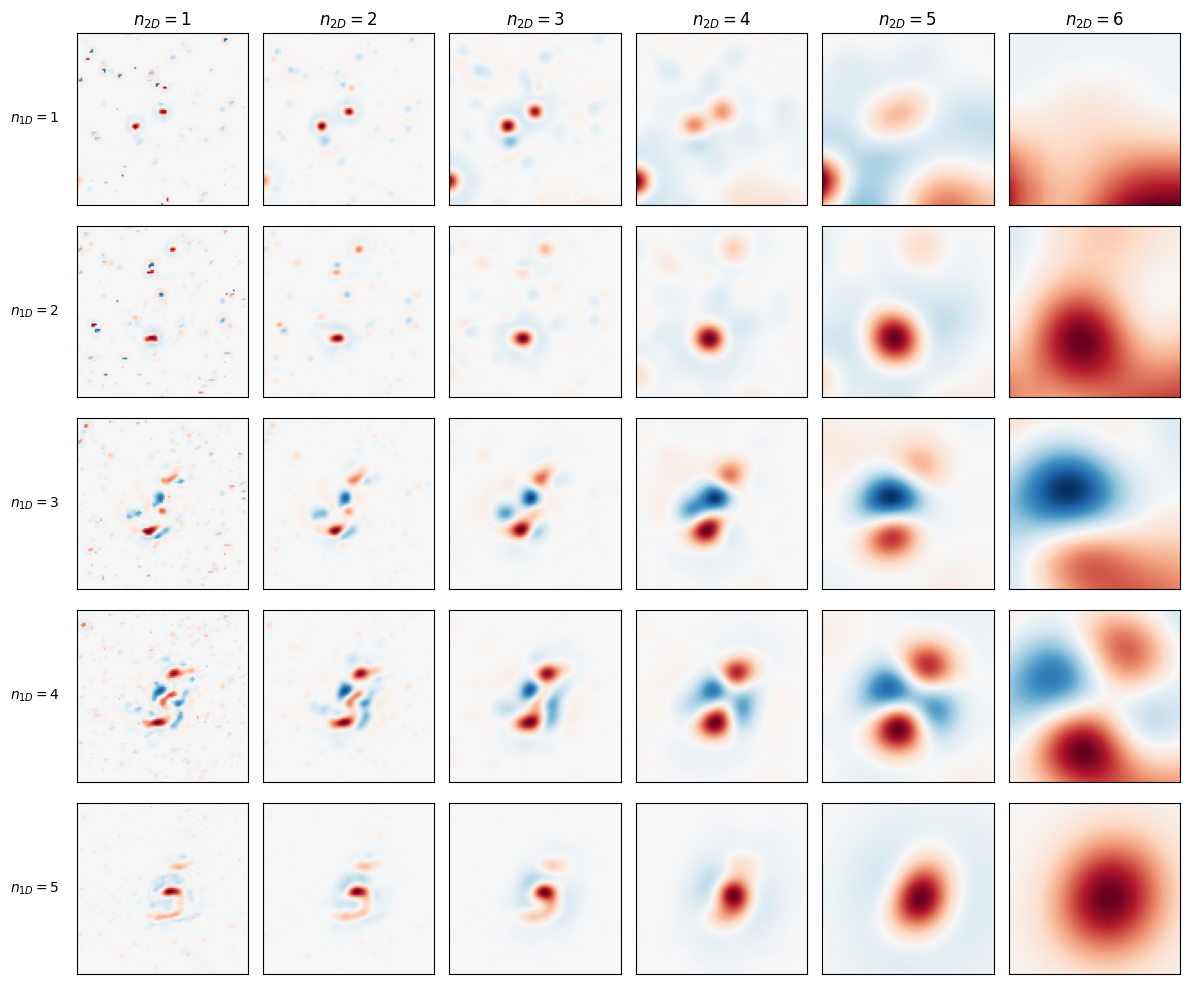

In [9]:
n2d = num_scales_2d_cube   # 6
n1d = num_scales_1d_cube   # 5

fig, axes = plt.subplots(
    n1d, n2d,
    figsize=(2 * n2d, 2 * n1d),
    squeeze=False,
)

for i in range(n2d):           # eje columnas: escala 2D
    for j in range(n1d):       # eje filas:    escala 1D
        nx, ny, nz = shapes[i][j]
        start, end = inds[i][j]
        sub = coeffs[start:end].reshape((nz, ny, nx))

        img = sub[nz // 2]                       # slice espectral central
        vmax = np.max(np.abs(img)) + 1e-12       # rango simétrico por celda
        ax = axes[j, i]
        ax.imshow(img, cmap="RdBu_r", vmin=-vmax, vmax=vmax, origin="lower")
        ax.set_xticks([]); ax.set_yticks([])

        if j == 0:
            ax.set_title(rf"$n_{{2D}} = {i+1}$")
        if i == 0:
            ax.set_ylabel(rf"$n_{{1D}} = {j+1}$", rotation=0, labelpad=30, va="center")

plt.tight_layout()
plt.savefig(os.path.join(IMGS_DIR, f'2D_slice_coeffs.png'))

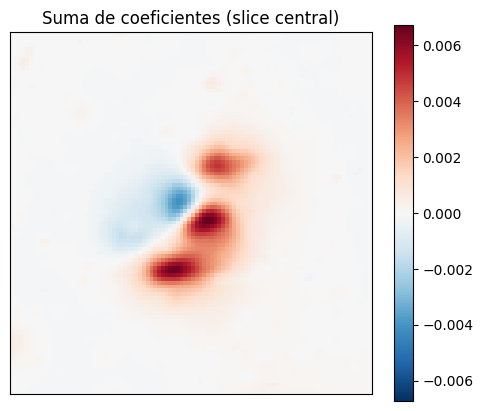

In [66]:
n2d = num_scales_2d_cube
n1d = num_scales_1d_cube

img_sum = None
for i in range(n2d):
    for j in range(n1d):
        nx, ny, nz = shapes[i][j]
        start, end = inds[i][j]
        sub = coeffs[start:end].reshape((nz, ny, nx))
        img = sub[nz // 2]                       # slice espectral central

        if img_sum is None:
            img_sum = img.astype(float).copy()
        else:
            img_sum += img

vmax = np.max(np.abs(img_sum)) + 1e-12

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(img_sum, cmap="RdBu_r", vmin=-vmax, vmax=vmax, origin="lower")
ax.set_title("Suma de coeficientes (slice central)")
ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

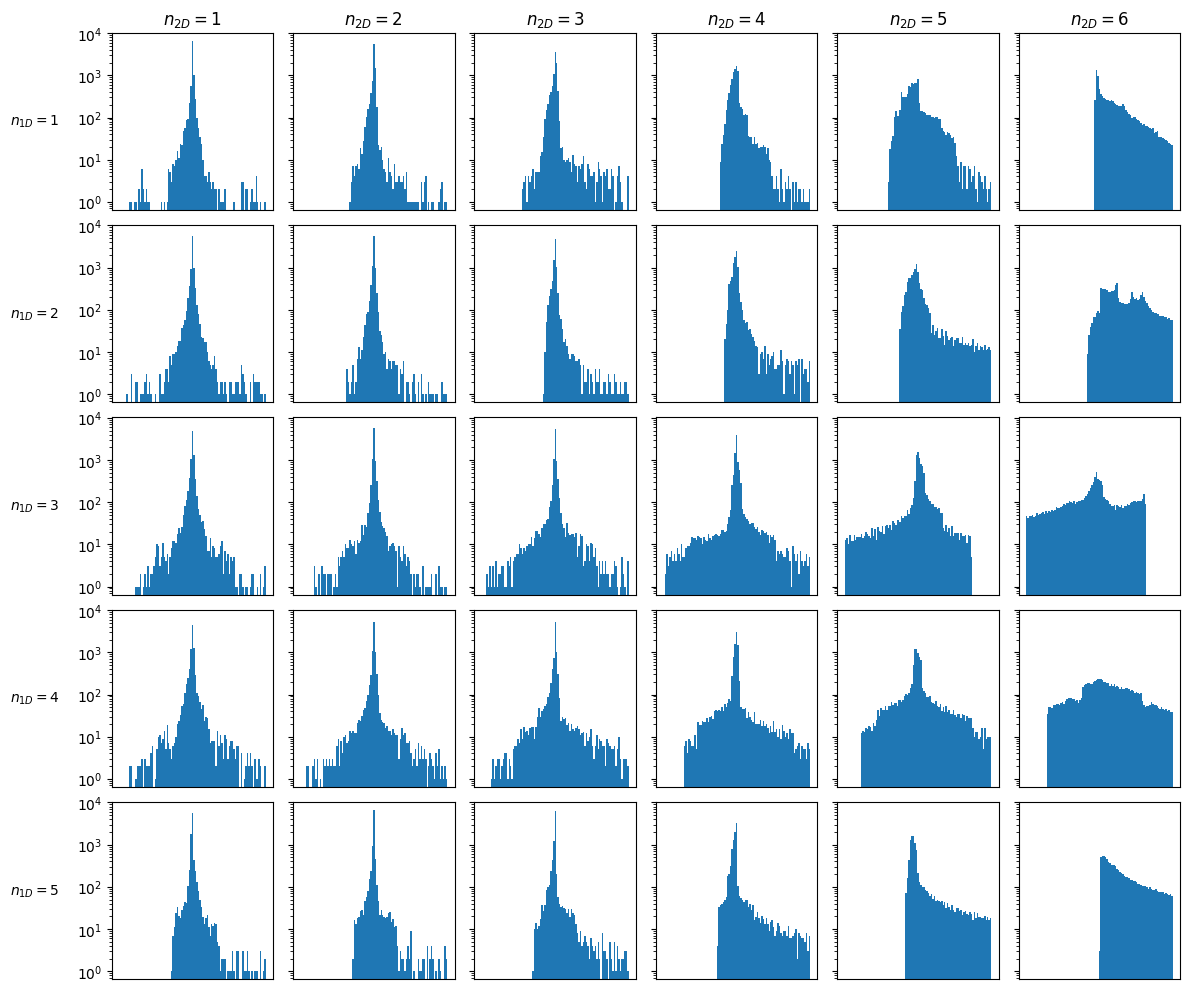

In [67]:
n2d = num_scales_2d_cube   # 6
n1d = num_scales_1d_cube   # 5

fig, axes = plt.subplots(
    n1d, n2d,
    figsize=(2 * n2d, 2 * n1d),
    squeeze=False,
    sharey=True,
)

for i in range(n2d):           # eje columnas: escala 2D
    for j in range(n1d):       # eje filas:    escala 1D
        nx, ny, nz = shapes[i][j]
        start, end = inds[i][j]
        sub = coeffs[start:end].reshape((nz, ny, nx))

        img = sub[nz // 2]                       # slice espectral central
        vmax = np.max(np.abs(img)) + 1e-12       # rango simétrico por celda
        bins = np.linspace(-vmax, vmax, 100)
        ax = axes[j, i]
        ax.hist(img.flatten(), bins=bins)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_yscale('log')

        if j == 0:
            ax.set_title(rf"$n_{{2D}} = {i+1}$")
        if i == 0:
            ax.set_ylabel(rf"$n_{{1D}} = {j+1}$", rotation=0, labelpad=30, va="center")

plt.tight_layout()
plt.show()

In [43]:
denoiser = Denoiser2D1D(threshold_type='soft', verbose=False, plot=False)

result = denoiser.denoise(
    x=cube,                 # cubo ruidoso
    y=cube,                 # ground truth (si no la tienes, usa el mismo cubo)
    method='iterative',
    threshold_level=3,      # k en k·sigma
    num_scales_2d=num_scales_2d_cube,
    num_scales_1d=num_scales_1d_cube,
    num_iter_reweight=20,
    debias=False,           # para esta figura no necesitas la fase de debias
)

(best_model, model_1_step, model_no_reweight,
 deltas, res_rw, res_db,
 best_iter, dists, noise_levels) = result

# dists[0] = Original    (antes de cualquier thresholding)
# dists[1] = iter 0      = "No Re-weighting"  (pesos=1)
# dists[2] = iter 1      = "Re-weight #1"
# dists[-1] = iter final = "Re-weight Final"

# noise_levels guarda sigma por sub-banda en orden (scale2d, scale1d):
# index = scale2d * n_bands_1d + scale1d
n_bands_1d = num_scales_1d_cube
diag_scale2d = min(5, num_scales_2d_cube - 2)   # = 4 para tu cubo
diag_scale1d = 0
sigma_band = noise_levels[diag_scale2d * n_bands_1d + diag_scale1d]
T = 3.0 * sigma_band

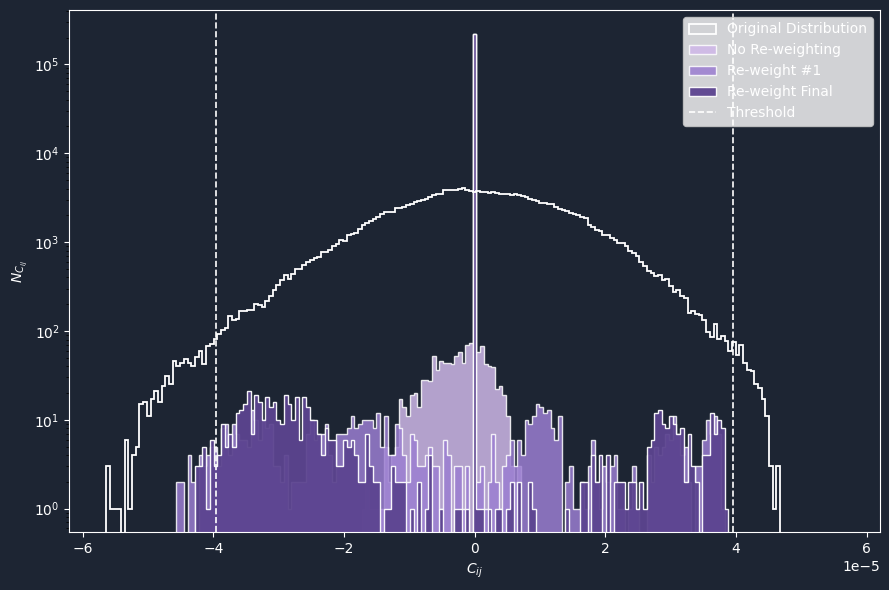

In [42]:
orig      = dists[0]
no_rw     = dists[1]
rw1       = dists[2]
rw_final  = dists[-1]

vmax = float(np.max(np.abs(orig)))
bins = np.linspace(-vmax, vmax, 200)

fig, ax = plt.subplots(figsize=(9, 6))

ax.hist(orig,     bins=bins, histtype='step',       lw=1.3,
        color='white',                          label='Original Distribution')
ax.hist(no_rw,    bins=bins, histtype='stepfilled', alpha=0.85,
        color='#cfb8e8', edgecolor='white',     label='No Re-weighting')
ax.hist(rw1,      bins=bins, histtype='stepfilled', alpha=0.85,
        color='#9b7ed1', edgecolor='white',     label='Re-weight #1')
ax.hist(rw_final, bins=bins, histtype='stepfilled', alpha=0.95,
        color='#5c4490', edgecolor='white',     label='Re-weight Final')

ax.axvline( T, color='white', linestyle='--', lw=1.2, label='Threshold')
ax.axvline(-T, color='white', linestyle='--', lw=1.2)

ax.set_yscale('log')
ax.set_xlabel(r'$C_{ij}$')
ax.set_ylabel(r'$N_{C_{ij}}$')
ax.legend()

# Estilo "fondo oscuro" como en la figura
fig.patch.set_facecolor('#1d2533')
ax.set_facecolor('#1d2533')
for spine in ax.spines.values():
    spine.set_color('white')
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.title.set_color('white')
for txt in ax.get_legend().get_texts():
    txt.set_color('white')

plt.tight_layout()
plt.show()